## **Регрессия для IC50**

In [57]:
#Импортируем библиотеки
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt

In [15]:
#Загружаем данные после предобработки
df = pd.read_csv('train_data_preprocessed.csv')
df.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,log_IC50,log_CC50,log_SI
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,3,0,1.979535,5.173221,3.371597
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,3,0,0.572014,1.856738,2.079442
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,3,0,5.415250,5.088474,0.542324
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,4,0,0.995333,4.690023,4.162553
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,4.683348,4.943576,0.832909


In [ ]:
#Оставляем только признаки
X = df.drop(columns=[
    'IC50, mM',
    'CC50, mM',
    'SI',
    'log_IC50',
    'log_CC50',
    'log_SI'
])

y = df['log_IC50']

#Удаление признаков с высокой корреляцией
corr_matrix = X.corr().abs()
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
high_corr_features = [
    column
    for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.95)
]

len(high_corr_features)
X = X.drop(columns=high_corr_features)

print("Удалено признаков:", len(high_corr_features))
print("Осталось признаков:", X.shape[1])

Удалено признаков: 33
Осталось признаков: 177


In [25]:
#Разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)
print(X_train.shape, X_test.shape)

# Масштабируем признаки
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


(800, 177) (201, 177)


In [48]:
#Для записи результатов
model_results = []

def add_result(model_name, cv_r2, y_true, y_pred):
    model_results.append({
        'model': model_name,
        'cv_r2': cv_r2,
        'test_r2': r2_score(y_true, y_pred),
        'test_mae': mean_absolute_error(y_true, y_pred),
        'test_rmse': np.sqrt(mean_squared_error(y_true, y_pred))
    })

In [49]:
#Линейная регрессия
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

pred = lr.predict(X_test_scaled)

print(f"R2 = {r2_score(y_test, pred):.4f}")
print(f"MAE = {mean_absolute_error(y_test, pred):.4f}")
print(f"RMSE = {np.sqrt(mean_squared_error(y_test, pred)):.4f}")
add_result('LinearRegression', np.nan, y_test, pred)

R2 = 0.1546
MAE = 1.3674
RMSE = 1.8040


In [50]:
# Ridge - регуляризация
ridge = {'alpha': [0.01, 0.1, 1, 10, 100, 300, 500]}

grid = GridSearchCV(Ridge(),ridge,scoring='r2',cv=5,n_jobs=-1)

grid.fit(X_train_scaled, y_train)

r_pred = grid.predict(X_test_scaled)

print('Лучшие параметры:', grid.best_params_)
print(f'CV R2 = {grid.best_score_:.4f}')
print(f'Test R2 = {r2_score(y_test, r_pred):.4f}')
print(f'Test MAE = {mean_absolute_error(y_test, r_pred):.4f}')
print(f'Test RMSE = {np.sqrt(mean_squared_error(y_test, r_pred)):.4f}')
add_result('Ridge', grid.best_score_, y_test, r_pred)

Лучшие параметры: {'alpha': 100}
CV R2 = 0.2632
Test R2 = 0.3244
Test MAE = 1.2816
Test RMSE = 1.6126


In [51]:
lasso = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1]
}

l_grid = GridSearchCV(
    Lasso(max_iter=10000),
    lasso,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

l_grid.fit(X_train_scaled, y_train)

l_pred = l_grid.predict(X_test_scaled)

print('Лучшие параметры:', l_grid.best_params_)
print(f'CV R2 = {l_grid.best_score_:.4f}')
print(f'Test R2 = {r2_score(y_test, l_pred):.4f}')
print(f'Test MAE = {mean_absolute_error(y_test, l_pred):.4f}')
print(f'Test RMSE = {np.sqrt(mean_squared_error(y_test, l_pred)):.4f}')
add_result('Lasso', l_grid.best_score_, y_test, l_pred)

Лучшие параметры: {'alpha': 0.01}
CV R2 = 0.2405
Test R2 = 0.3229
Test MAE = 1.2672
Test RMSE = 1.6144


In [52]:
#RandomForest
rf_params = {
    'n_estimators': [200, 400],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

rf_grid.fit(X_train_scaled, y_train)

rf_pred = rf_grid.predict(X_test_scaled)

print('Лучшие параметры:', rf_grid.best_params_)
print(f'CV R2 = {rf_grid.best_score_:.4f}')
print(f'Test R2 = {r2_score(y_test, rf_pred):.4f}')
print(f'Test MAE = {mean_absolute_error(y_test, rf_pred):.4f}')
print(f'Test RMSE = {np.sqrt(mean_squared_error(y_test, rf_pred)):.4f}')
add_result('RandomForest', rf_grid.best_score_, y_test, rf_pred)

Лучшие параметры: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 400}
CV R2 = 0.3912
Test R2 = 0.4563
Test MAE = 1.1417
Test RMSE = 1.4466


In [53]:
#GradientBoostingRegressor
gb_params = {
    'n_estimators': [200, 400],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_params,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

gb_grid.fit(X_train_scaled, y_train)

gb_pred = gb_grid.predict(X_test_scaled)

print('Лучшие параметры:', gb_grid.best_params_)
print(f'CV R2 = {gb_grid.best_score_:.4f}')
print(f'Test R2 = {r2_score(y_test, gb_pred):.4f}')
print(f'Test MAE = {mean_absolute_error(y_test, gb_pred):.4f}')
print(f'Test RMSE = {np.sqrt(mean_squared_error(y_test, gb_pred)):.4f}')
add_result('GradientBoosting', gb_grid.best_score_, y_test, gb_pred)

Лучшие параметры: {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 200}
CV R2 = 0.3808
Test R2 = 0.4389
Test MAE = 1.1836
Test RMSE = 1.4697


In [55]:
#Сравнение моделей
results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(
    by='test_r2',
    ascending=False
).reset_index(drop=True)

results_df

,model,cv_r2,test_r2,test_mae,test_rmse
0,RandomForest,0.391226,0.456320,1.141713,1.446624
1,GradientBoosting,0.380760,0.438868,1.183612,1.469659
2,Ridge,0.263187,0.324446,1.281646,1.612553
3,Lasso,0.240457,0.322877,1.267158,1.614425
4,LinearRegression,NaN,0.154558,1.367361,1.803956


In [ ]:
#Подбор гиперпараметров
rf_base = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": randint(200, 800),
    "max_depth": randint(5, 40),
    "min_samples_split": randint(2, 15),
    "min_samples_leaf": randint(1, 8),
    "max_features": ["sqrt", "log2", None]
}

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=50,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

rf_pred = rf_search.predict(X_test)

print("Лучшие гиперпараметры:")
print(rf_search.best_params_)

print(f"\nCV R2 = {rf_search.best_score_:.4f}")
print(f"Test R2 = {r2_score(y_test, rf_pred):.4f}")
print(f"Test MAE = {mean_absolute_error(y_test, rf_pred):.4f}")
print(f"Test RMSE = {np.sqrt(mean_squared_error(y_test, rf_pred)):.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Лучшие гиперпараметры:
{'max_depth': 31, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 458}

CV R2 = 0.4046
Test R2 = 0.4725
Test MAE = 1.1327
Test RMSE = 1.4250


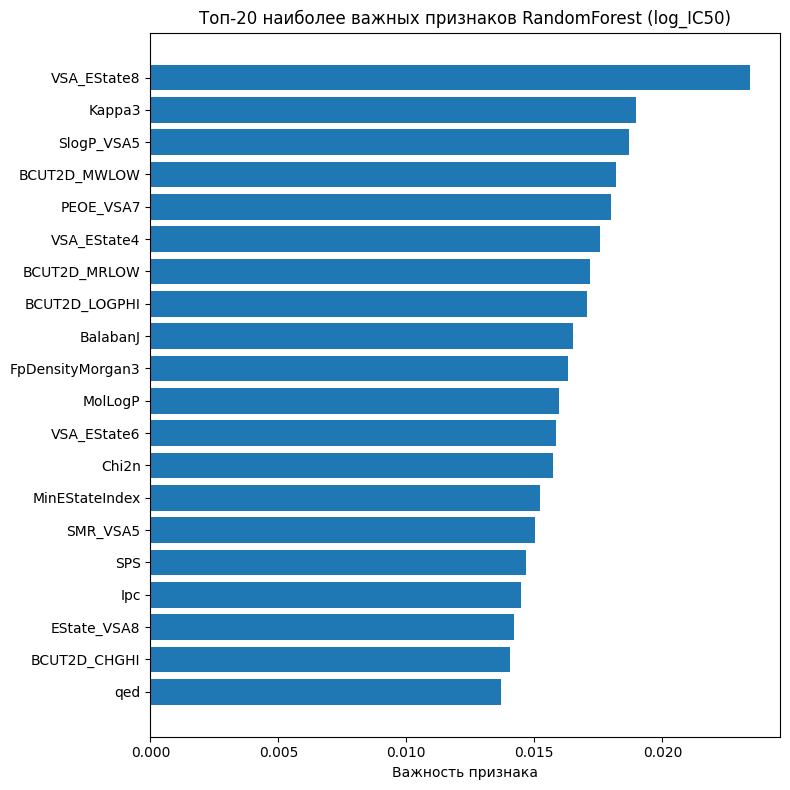

In [58]:
best_rf = rf_search.best_estimator_

importances = best_rf.feature_importances_
feature_names = X.columns
idx = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(8, 8))
plt.barh(
    range(len(idx)),
    importances[idx][::-1]
)
plt.yticks(
    range(len(idx)),
    feature_names[idx][::-1]
)
plt.xlabel("Важность признака")
plt.title("Топ-20 наиболее важных признаков RandomForest (log_IC50)")

plt.tight_layout()
plt.show()

Отметим, что данные признаки вошли в топ-20 после удаления сильно скоррелированных признаков. Ниже показан список удаленных признаков

In [59]:
removed_features_df = pd.DataFrame(
    high_corr_features,
    columns=["Удалённые признаки (высокая корреляция)"]
)

removed_features_df

,Удалённые признаки (высокая корреляция)
0,MaxEStateIndex
1,HeavyAtomMolWt
2,ExactMolWt
3,NumValenceElectrons
4,MinAbsPartialCharge
5,Chi0
6,Chi0n
7,Chi0v
8,Chi1
9,Chi1n


Вывод: В ходе работы я предобработал данные - произвел снижение размерности и масштабирование признаков. Сравнил модели LinearRegression (до и после применения Ridge и lasso) с RandomForest и GradientBoosting. Наилучшая модель - RandomForest, для которой были подобраны гиперпараметры с помощью RandomizedSearchCV. Наиболее значимый признак - VSA_EState8, который отражает площадь поверхности атомов молекулы, попадающих в определённый диапазон электропологического состояния (EState).